# Exploratory Data Analysis — 30-Day Hospital Readmission Predictor
**Karam Issa | kissa3@gatech.edu**

This notebook explores the parsed FHIR feature matrix before modeling. Goals:
- Understand the distribution of each feature
- Identify relationships between features and the readmission label
- Spot any data quality issues that need handling in preprocessing


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 120

# Load data
df = pd.read_csv("../data/processed/features.csv")
print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (102373, 12)


,patient_id,encounter_id,age,gender,length_of_stay_days,prior_admissions,num_conditions,num_medications,num_procedures,has_prior_ed_visit,enc_class,readmitted_30d
0,402622e0-7b57-93f1-a88c-e54643386c73,402622e0-7b57-93f1-1b10-a69dc2571eeb,0.6,female,0.13,0,0,0,1,0,EMER,0
1,402622e0-7b57-93f1-a88c-e54643386c73,402622e0-7b57-93f1-2c0c-f281a78686fa,3.7,female,0.04,1,1,6,0,0,EMER,0
2,402622e0-7b57-93f1-a88c-e54643386c73,402622e0-7b57-93f1-9a84-92eb486ed0ba,3.7,female,2.01,2,1,6,8,0,IMP,0
3,402622e0-7b57-93f1-a88c-e54643386c73,402622e0-7b57-93f1-f685-9bd080625d6f,10.1,female,0.04,3,1,13,2,0,EMER,0
4,402622e0-7b57-93f1-a88c-e54643386c73,402622e0-7b57-93f1-a494-c0b2ecace60a,20.3,female,0.04,4,2,20,2,0,EMER,0


## 1. Dataset Overview

In [2]:
print("=== Shape ===")
print(f"{len(df):,} encounter rows | {df['patient_id'].nunique():,} unique patients")
print()
print("=== Data Types ===")
print(df.dtypes)
print()
print("=== Missing Values ===")
print(df.isnull().sum())


=== Shape ===
102,373 encounter rows | 10,243 unique patients

=== Data Types ===
patient_id                 str
encounter_id               str
age                    float64
gender                     str
length_of_stay_days    float64
prior_admissions         int64
num_conditions           int64
num_medications          int64
num_procedures           int64
has_prior_ed_visit       int64
enc_class                  str
readmitted_30d           int64
dtype: object

=== Missing Values ===
patient_id             0
encounter_id           0
age                    0
gender                 0
length_of_stay_days    0
prior_admissions       0
num_conditions         0
num_medications        0
num_procedures         0
has_prior_ed_visit     0
enc_class              0
readmitted_30d         0
dtype: int64


In [3]:
print("=== Basic Statistics ===")
df.describe().round(2)


=== Basic Statistics ===


,age,length_of_stay_days,prior_admissions,num_conditions,num_medications,num_procedures,has_prior_ed_visit,readmitted_30d
count,102373.00,102373.00,102373.00,102373.00,102373.00,102373.00,102373.00,102373.0
mean,35.69,1.97,16.00,6.40,135.62,4.10,0.26,0.1
std,22.43,13.76,33.61,6.32,406.29,10.74,0.44,0.3
min,0.00,0.04,0.00,0.00,0.00,0.00,0.00,0.0
25%,18.10,0.04,2.00,2.00,12.00,0.00,0.00,0.0
50%,31.60,0.04,6.00,5.00,25.00,1.00,0.00,0.0
75%,51.40,0.10,16.00,9.00,70.00,2.00,1.00,0.0
max,110.70,3834.12,466.00,39.00,5171.00,174.00,1.00,1.0


## 2. Target Variable — Class Distribution
The target is `readmitted_30d` (1 = readmitted within 30 days, 0 = not readmitted).
A significant class imbalance is expected — readmission is a relatively rare event.


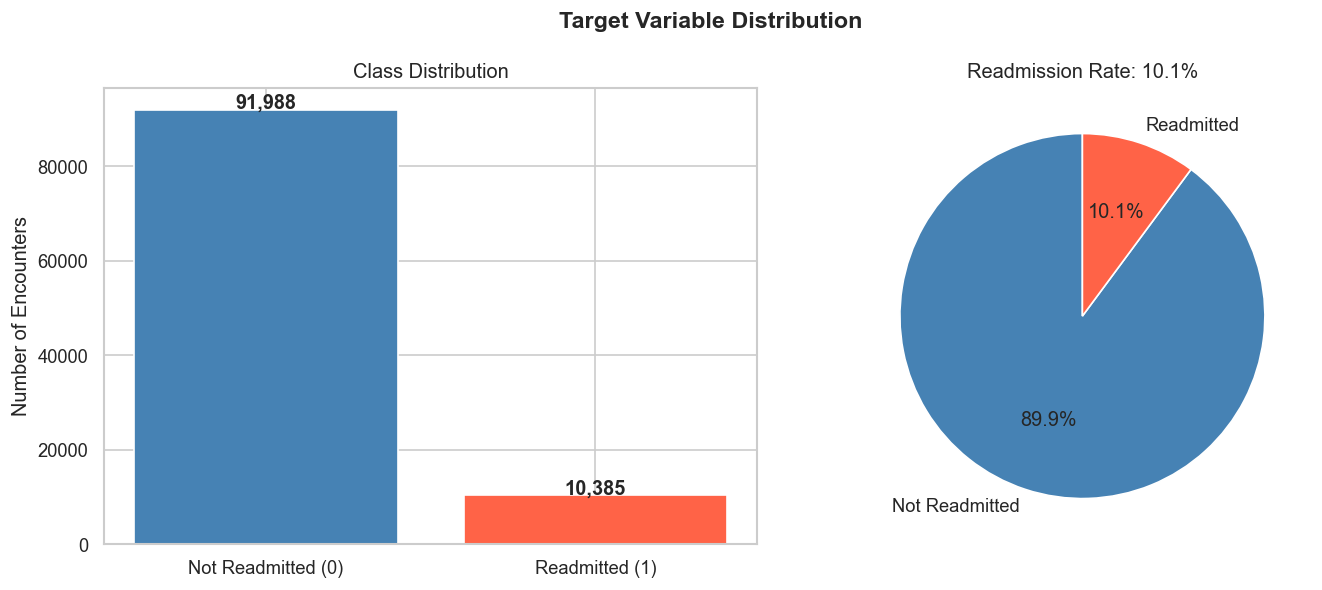

Readmission rate: 10.1%
Class ratio (negative:positive): 8.9:1


In [4]:
counts = df['readmitted_30d'].value_counts()
rate   = df['readmitted_30d'].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axes[0].bar(['Not Readmitted (0)', 'Readmitted (1)'], counts.values,
            color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Number of Encounters')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['Not Readmitted', 'Readmitted'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'],
            startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title(f'Readmission Rate: {rate:.1%}')

plt.suptitle('Target Variable Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/01_class_distribution.png', bbox_inches='tight')
plt.show()
print(f"Readmission rate: {rate:.1%}")
print(f"Class ratio (negative:positive): {counts[0]/counts[1]:.1f}:1")


## 3. Age Distribution
Age at time of admission. We expect readmission risk to increase with age,
consistent with the clinical literature.


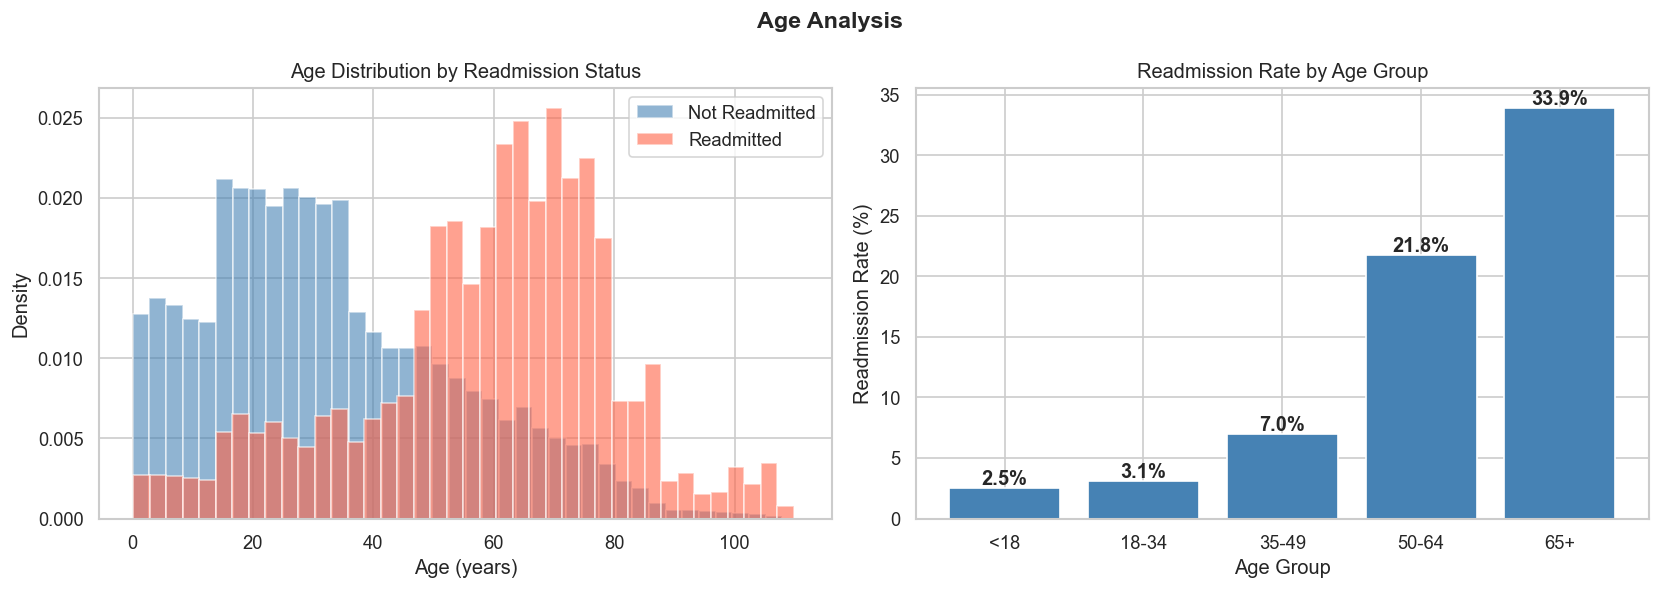

Readmission rate by age group:
            mean  count
age_group              
<18        0.025  25516
18-34      0.031  31646
35-49      0.070  17946
50-64      0.218  14127
65+        0.339  13120


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram by readmission status
for label, color, name in [(0, 'steelblue', 'Not Readmitted'), (1, 'tomato', 'Readmitted')]:
    axes[0].hist(df[df['readmitted_30d'] == label]['age'],
                 bins=40, alpha=0.6, color=color, label=name, density=True)
axes[0].set_title('Age Distribution by Readmission Status')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Readmission rate by age group
df['age_group'] = pd.cut(df['age'],
                          bins=[0, 18, 35, 50, 65, 120],
                          labels=['<18', '18-34', '35-49', '50-64', '65+'])
age_stats = df.groupby('age_group')['readmitted_30d'].mean() * 100

axes[1].bar(age_stats.index, age_stats.values, color='steelblue', edgecolor='white')
axes[1].set_title('Readmission Rate by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Readmission Rate (%)')
for i, v in enumerate(age_stats.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Age Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/02_age_distribution.png', bbox_inches='tight')
plt.show()

print("Readmission rate by age group:")
print(df.groupby('age_group')['readmitted_30d'].agg(['mean', 'count']).round(3))


## 4. Length of Stay
Length of stay (LOS) in days. Note the extreme outlier (3,834 days) — this will be
capped at 30 days during preprocessing.


/var/folders/5b/brdz2v0j69qfhxg9z1ywjdh40000gn/T/ipykernel_45525/865213511.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_capped, x='Readmission', y='los_capped',


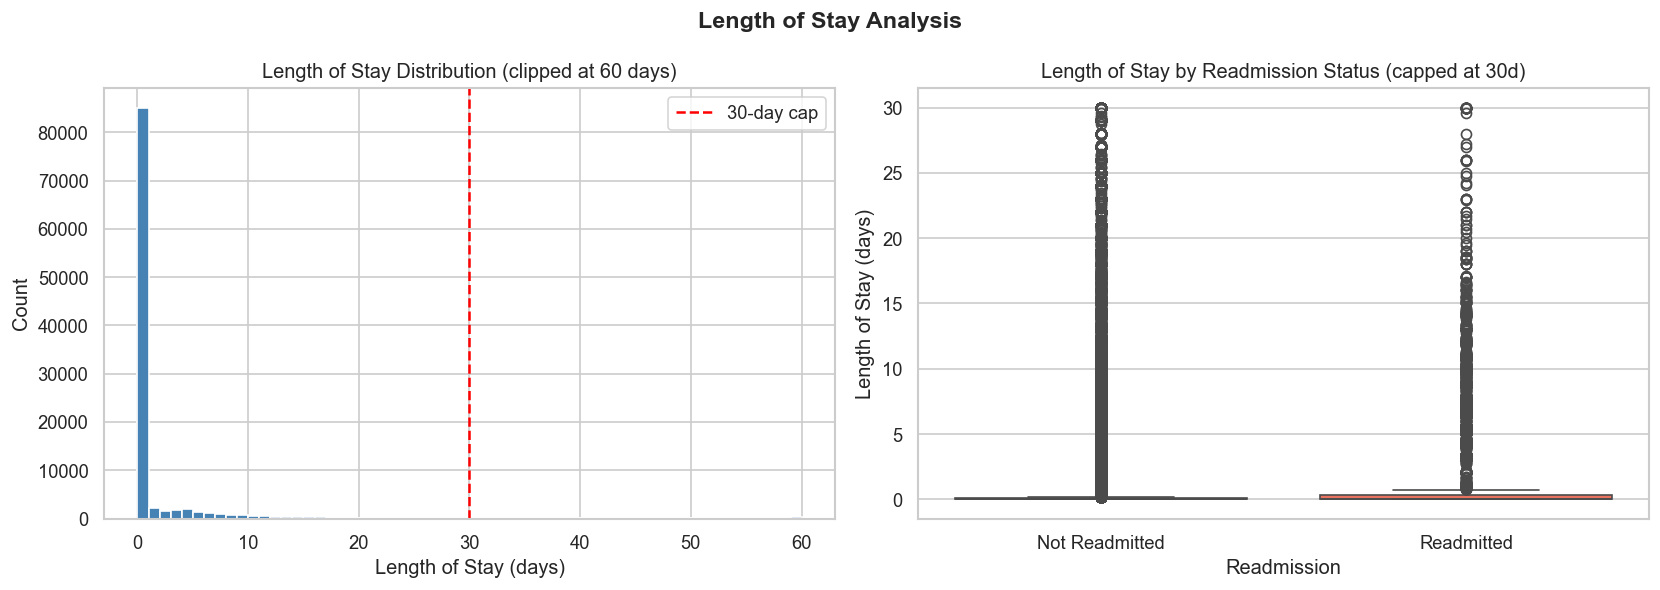

LOS stats by readmission status:
                  count  mean    std   min   25%   50%   75%      max
readmitted_30d                                                       
0               91988.0  2.04  14.45  0.04  0.04  0.04  0.10  3834.12
1               10385.0  1.38   3.91  0.04  0.04  0.04  0.33   100.01

Outlier: max LOS = 3834.1 days → will be capped at 30


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw distribution (log scale to handle outliers)
axes[0].hist(df['length_of_stay_days'].clip(upper=60), bins=60,
             color='steelblue', edgecolor='white')
axes[0].set_title('Length of Stay Distribution (clipped at 60 days)')
axes[0].set_xlabel('Length of Stay (days)')
axes[0].set_ylabel('Count')
axes[0].axvline(30, color='red', linestyle='--', label='30-day cap')
axes[0].legend()

# Boxplot by readmission
df_capped = df.copy()
df_capped['los_capped'] = df_capped['length_of_stay_days'].clip(upper=30)
df_capped['Readmission'] = df_capped['readmitted_30d'].map({0: 'Not Readmitted', 1: 'Readmitted'})

sns.boxplot(data=df_capped, x='Readmission', y='los_capped',
            palette={'Not Readmitted': 'steelblue', 'Readmitted': 'tomato'}, ax=axes[1])
axes[1].set_title('Length of Stay by Readmission Status (capped at 30d)')
axes[1].set_ylabel('Length of Stay (days)')

plt.suptitle('Length of Stay Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/03_length_of_stay.png', bbox_inches='tight')
plt.show()

print("LOS stats by readmission status:")
print(df.groupby('readmitted_30d')['length_of_stay_days'].describe().round(2))
print(f"\nOutlier: max LOS = {df['length_of_stay_days'].max():.1f} days → will be capped at 30")


## 5. Conditions & Medications
Number of active conditions and medications at time of admission.
These are expected to be strong predictors — sicker patients get readmitted more.


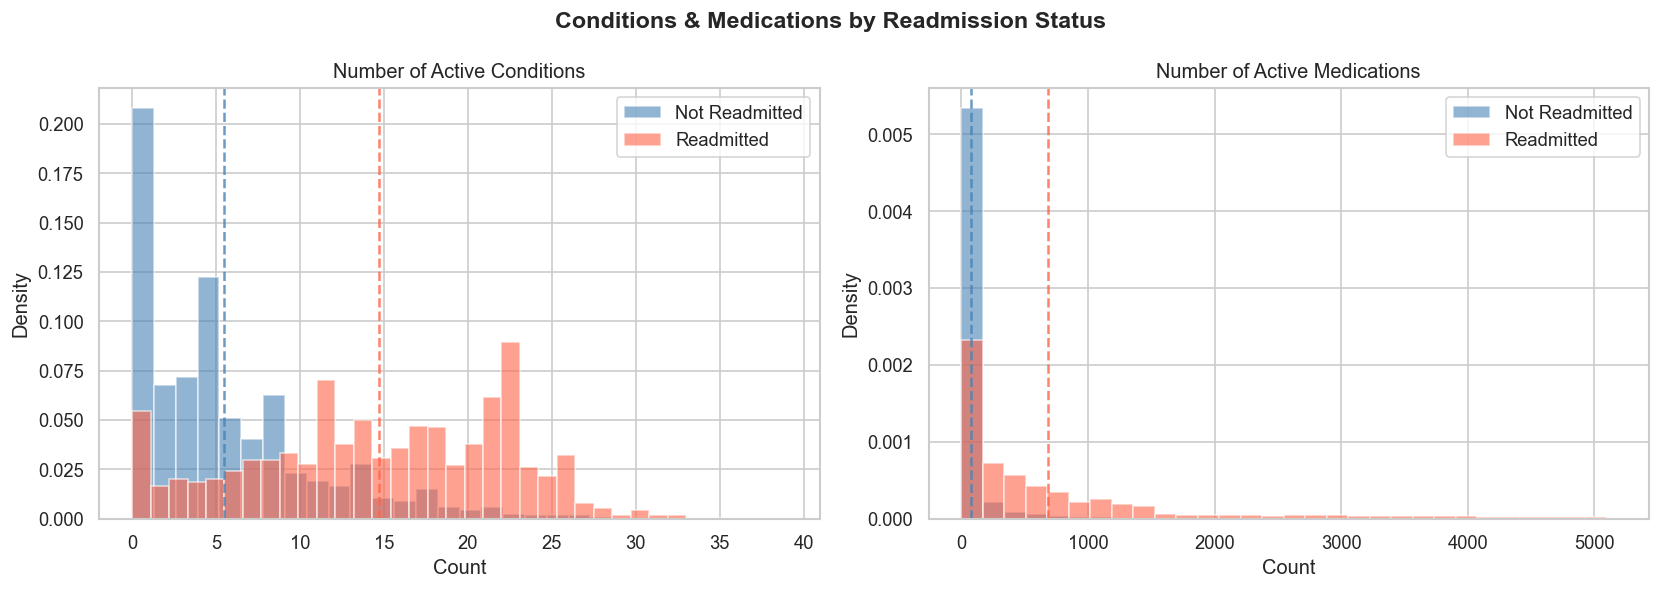

Mean conditions by readmission:
readmitted_30d
0     5.47
1    14.69
Name: num_conditions, dtype: float64

Mean medications by readmission:
readmitted_30d
0     73.61
1    684.81
Name: num_medications, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in [
    (axes[0], 'num_conditions', 'Number of Active Conditions'),
    (axes[1], 'num_medications', 'Number of Active Medications'),
]:
    for label, color, name in [(0, 'steelblue', 'Not Readmitted'), (1, 'tomato', 'Readmitted')]:
        ax.hist(df[df['readmitted_30d'] == label][col],
                bins=30, alpha=0.6, color=color, label=name, density=True)
    ax.set_title(title)
    ax.set_xlabel('Count')
    ax.set_ylabel('Density')
    ax.legend()

    means = df.groupby('readmitted_30d')[col].mean()
    ax.axvline(means[0], color='steelblue', linestyle='--', alpha=0.8)
    ax.axvline(means[1], color='tomato', linestyle='--', alpha=0.8)

plt.suptitle('Conditions & Medications by Readmission Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/04_conditions_medications.png', bbox_inches='tight')
plt.show()

print("Mean conditions by readmission:")
print(df.groupby('readmitted_30d')['num_conditions'].mean().round(2))
print()
print("Mean medications by readmission:")
print(df.groupby('readmitted_30d')['num_medications'].mean().round(2))


## 6. Prior Admissions & ED Visits
Prior utilization history is a well-established predictor of readmission.


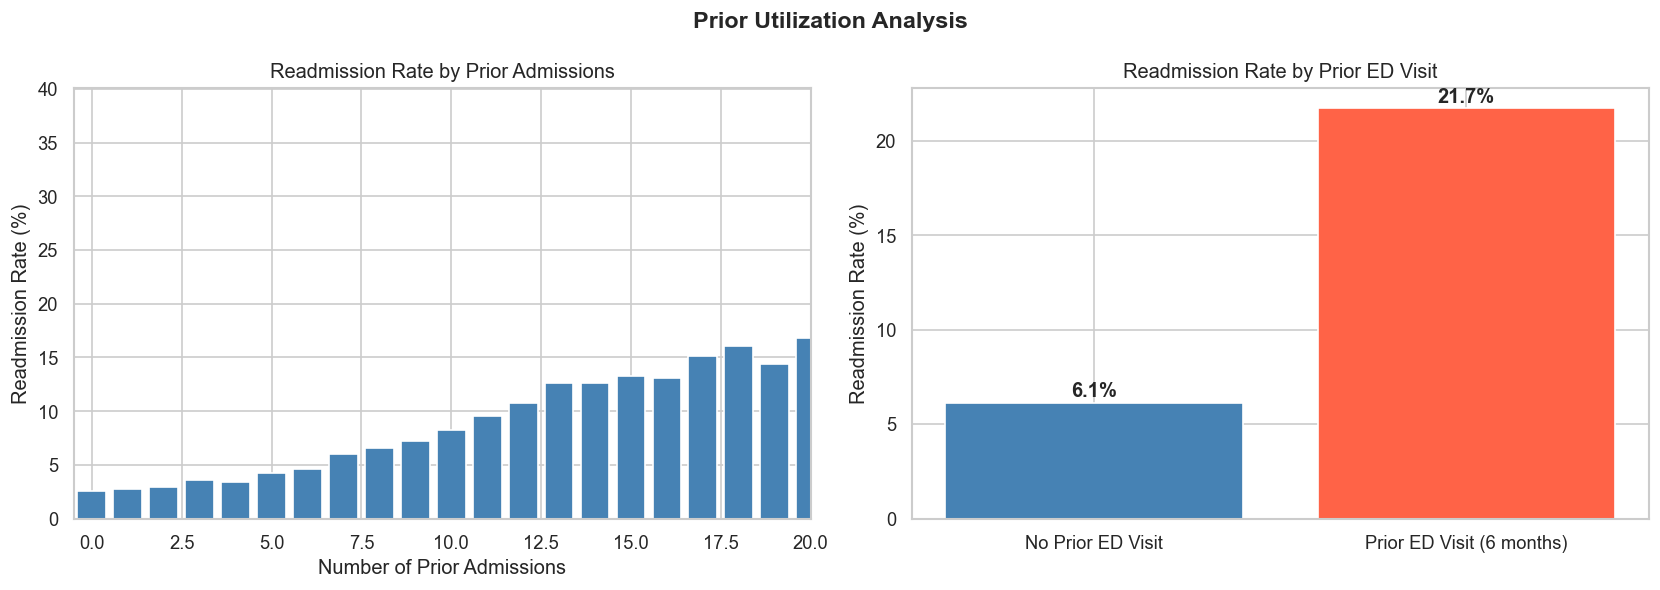

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prior admissions distribution
prior_stats = df.groupby('prior_admissions')['readmitted_30d'].agg(['mean', 'count'])
prior_stats = prior_stats[prior_stats['count'] > 50]  # filter low-count buckets

axes[0].bar(prior_stats.index, prior_stats['mean'] * 100, color='steelblue', edgecolor='white')
axes[0].set_title('Readmission Rate by Prior Admissions')
axes[0].set_xlabel('Number of Prior Admissions')
axes[0].set_ylabel('Readmission Rate (%)')
axes[0].set_xlim(-0.5, 20)

# Prior ED visit
ed_stats = df.groupby('has_prior_ed_visit')['readmitted_30d'].mean() * 100
axes[1].bar(['No Prior ED Visit', 'Prior ED Visit (6 months)'],
            ed_stats.values, color=['steelblue', 'tomato'], edgecolor='white')
axes[1].set_title('Readmission Rate by Prior ED Visit')
axes[1].set_ylabel('Readmission Rate (%)')
for i, v in enumerate(ed_stats.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Prior Utilization Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/05_prior_utilization.png', bbox_inches='tight')
plt.show()


## 7. Feature Correlations
Correlation of all numeric features with the target variable, and a heatmap
showing inter-feature correlations. High inter-feature correlation can indicate
multicollinearity.


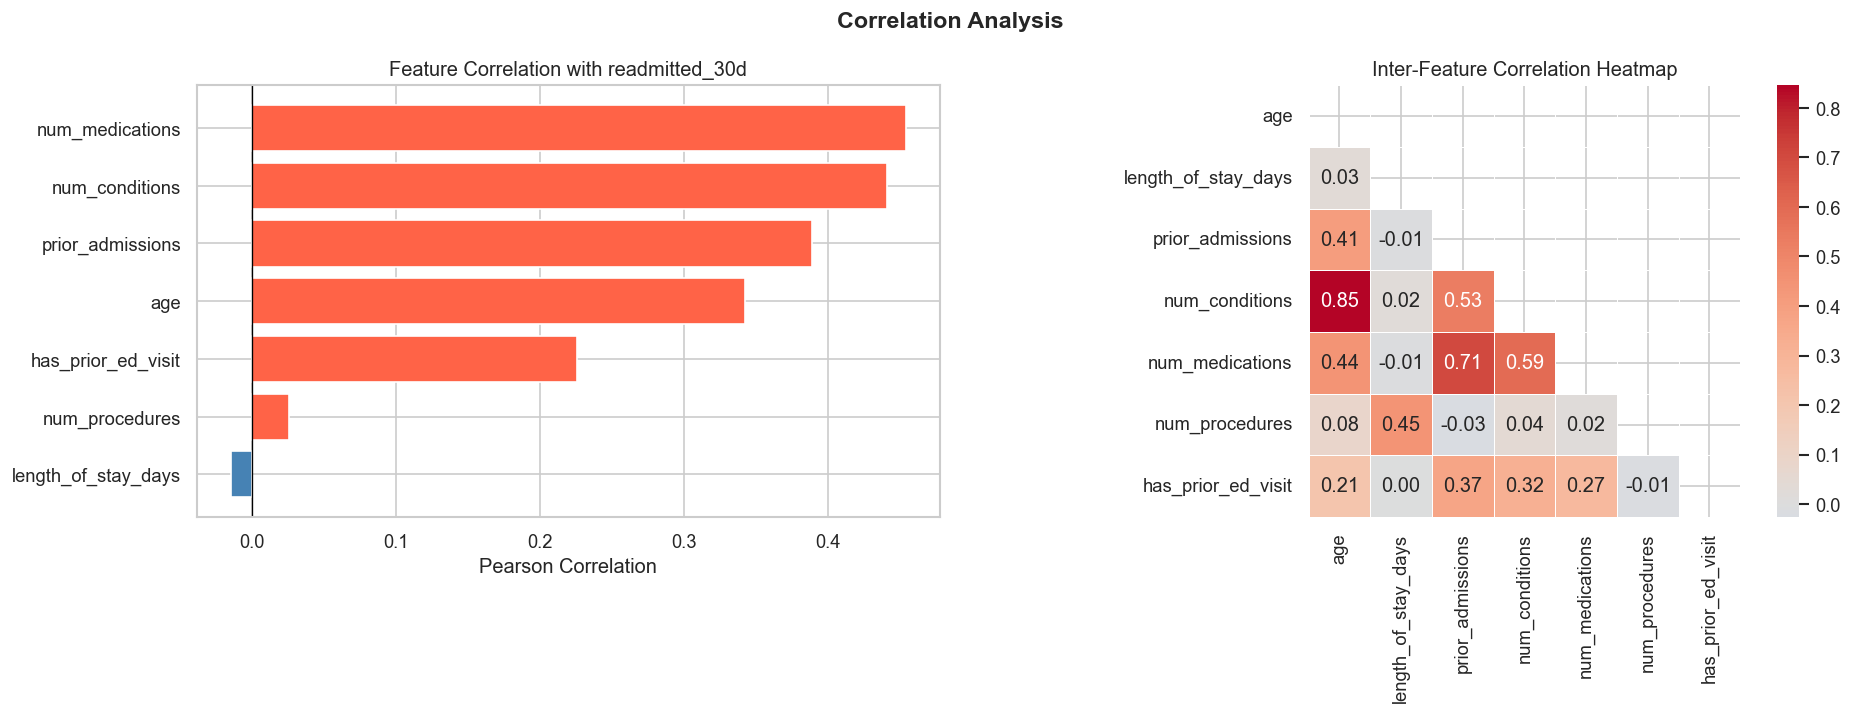

Top correlations with readmitted_30d:
num_medications        0.4542
num_conditions         0.4408
prior_admissions       0.3891
age                    0.3427
has_prior_ed_visit     0.2257
num_procedures         0.0257
length_of_stay_days   -0.0145
dtype: float64


In [9]:
numeric_df = df.select_dtypes(include=np.number).drop(columns=['readmitted_30d'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Correlation with target
target_corr = numeric_df.corrwith(df['readmitted_30d']).sort_values(ascending=True)
colors = ['tomato' if v > 0 else 'steelblue' for v in target_corr.values]
axes[0].barh(target_corr.index, target_corr.values, color=colors, edgecolor='white')
axes[0].set_title('Feature Correlation with readmitted_30d')
axes[0].set_xlabel('Pearson Correlation')
axes[0].axvline(0, color='black', linewidth=0.8)

# Heatmap
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=axes[1],
            square=True, linewidths=0.5)
axes[1].set_title('Inter-Feature Correlation Heatmap')

plt.suptitle('Correlation Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/06_correlations.png', bbox_inches='tight')
plt.show()

print("Top correlations with readmitted_30d:")
print(target_corr.sort_values(ascending=False).round(4))


## 8. Gender & Encounter Type

/var/folders/5b/brdz2v0j69qfhxg9z1ywjdh40000gn/T/ipykernel_45525/3951817738.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Emergency (EMER)', 'Inpatient (IMP)'])


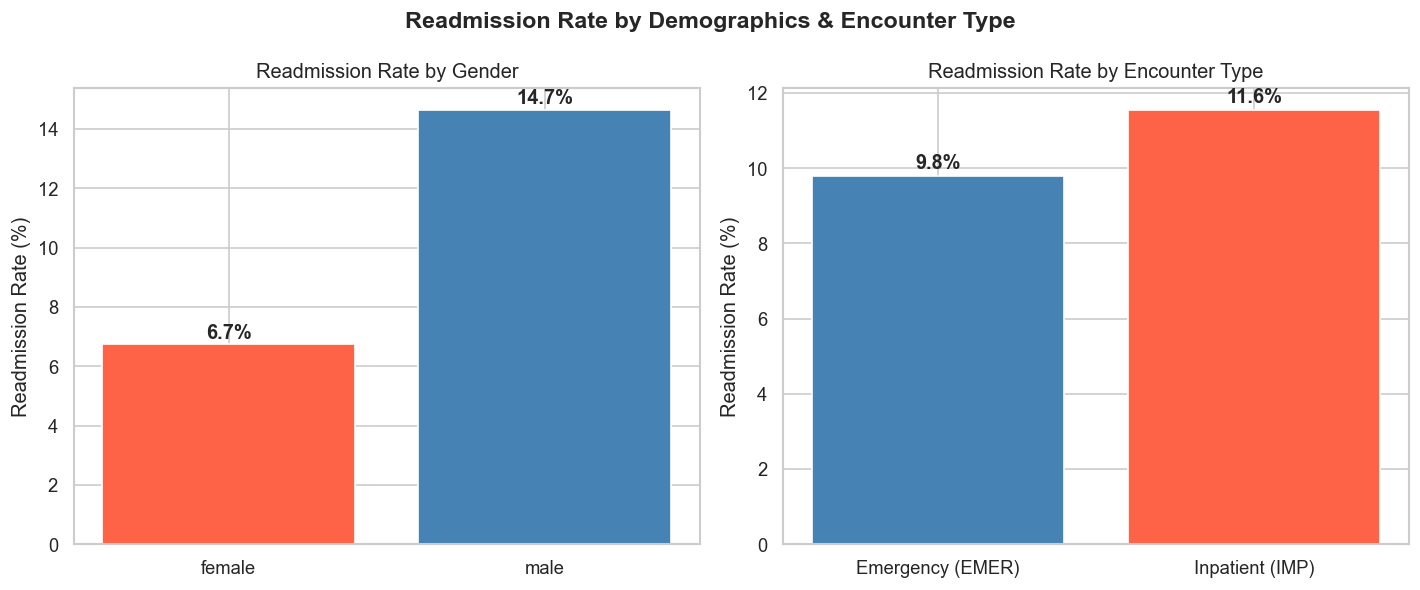

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gender
gender_stats = df.groupby('gender')['readmitted_30d'].mean() * 100
axes[0].bar(gender_stats.index, gender_stats.values,
            color=['tomato', 'steelblue'], edgecolor='white')
axes[0].set_title('Readmission Rate by Gender')
axes[0].set_ylabel('Readmission Rate (%)')
for i, v in enumerate(gender_stats.values):
    axes[0].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')

# Encounter class
enc_stats = df.groupby('enc_class')['readmitted_30d'].mean() * 100
axes[1].bar(enc_stats.index, enc_stats.values,
            color=['steelblue', 'tomato'], edgecolor='white')
axes[1].set_title('Readmission Rate by Encounter Type')
axes[1].set_ylabel('Readmission Rate (%)')
axes[1].set_xticklabels(['Emergency (EMER)', 'Inpatient (IMP)'])
for i, v in enumerate(enc_stats.values):
    axes[1].text(i, v + 0.2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('Readmission Rate by Demographics & Encounter Type',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/07_gender_encounter.png', bbox_inches='tight')
plt.show()


## 9. Key Findings & Preprocessing Decisions

Based on this EDA, the following decisions will be made in `preprocess.py`:

| Finding | Action |
|---|---|
| 25,516 pediatric encounters (age < 18) | Filter to adults only (age ≥ 18) — HRRP is adult-focused |
| LOS outlier: max = 3,834 days | Cap at 30 days |
| `gender` is categorical (male/female) | Encode as binary: `gender_male` (0/1) |
| `enc_class` is categorical (EMER/IMP) | Encode as binary: `is_inpatient` (0/1) |
| Class imbalance: 90% negative, 10% positive | Use `class_weight='balanced'` in models |
| `num_medications` and `num_conditions` are highly correlated (r=0.85+) | Keep both for now — tree models handle this well |

**Strongest predictors of readmission (by correlation):**
1. `num_medications` (r = 0.45)
2. `num_conditions` (r = 0.44)
3. `prior_admissions` (r = 0.39)
4. `age` (r = 0.34)
5. `has_prior_ed_visit` (r = 0.23)
